In [2]:
import numpy as np

np.random.seed(42)

indices = np.random.permutation(50000)  

train_idx = indices[:5000]
val_idx = indices[5000:6000]

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from Util.customDatasetConverter import TrainDataset, TestDataset, get_transform
from torch.utils.data import DataLoader, random_split
import torch


In [4]:
transform = get_transform()

full_train_dataset = TrainDataset(transform=transform)
test_dataset = TestDataset(transform=transform)

print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", full_train_dataset.classes)

Train size: 50000
Test size: 300000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Data Normalization

In [5]:
def get_transform():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

Augmentation

In [6]:
def get_train_transform():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),
                             (0.5,0.5,0.5))
    ])

train Test split


In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import numpy as np

In [8]:
##full_dataset = TrainDataset(transform=None)

#indices = np.arange(len(full_dataset))

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
transform = transforms.ToTensor()

full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
import numpy as np

np.random.seed(42)
indices = np.random.permutation(len(full_train))

train_idx = indices[:5000]
val_idx = indices[5000:6000]

d:\AiProject2\AI20\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
        random_state=42,
        shuffle=True
)


Train: 40000
Val: 10000


optional

In [9]:
train_dataset = Subset(full_train, train_idx)
val_dataset = Subset(full_train, val_idx)

print("Train:", len(train_idx))
print("Val:", len(val_idx))

Train: 5000
Val: 1000


In [10]:
from torchvision import transforms

def get_train_transform():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()
    ])

def get_test_transform():
    return transforms.Compose([
        transforms.ToTensor()
    ])

In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import numpy as np

full_dataset = TrainDataset(transform=None)

indices = np.arange(len(full_dataset))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

สร้าง dataset

In [12]:
train_dataset = Subset(
    TrainDataset(transform=get_train_transform()),
    train_idx
)

val_dataset = Subset(
    TrainDataset(transform=get_test_transform()),
    val_idx
)

สร้าง DataLoader

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

create model

In [14]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

ตั้ง device, loss, optimizer

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = SimpleCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

cuda


ฟังก์ชัน train / validate

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

เทรน model

In [17]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_labels, val_preds = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

Epoch [1/10]
Train Loss: 1.7274 | Train Acc: 0.3578
Val   Loss: 1.4578 | Val   Acc: 0.4747
----------------------------------------
Epoch [2/10]
Train Loss: 1.4203 | Train Acc: 0.4862
Val   Loss: 1.2402 | Val   Acc: 0.5482
----------------------------------------
Epoch [3/10]
Train Loss: 1.2722 | Train Acc: 0.5431
Val   Loss: 1.0993 | Val   Acc: 0.6053
----------------------------------------
Epoch [4/10]
Train Loss: 1.1705 | Train Acc: 0.5849
Val   Loss: 1.0213 | Val   Acc: 0.6376
----------------------------------------
Epoch [5/10]
Train Loss: 1.0799 | Train Acc: 0.6161
Val   Loss: 0.9407 | Val   Acc: 0.6624
----------------------------------------
Epoch [6/10]
Train Loss: 1.0263 | Train Acc: 0.6401
Val   Loss: 0.8798 | Val   Acc: 0.6874
----------------------------------------
Epoch [7/10]
Train Loss: 0.9688 | Train Acc: 0.6583
Val   Loss: 0.8402 | Val   Acc: 0.7083
----------------------------------------
Epoch [8/10]
Train Loss: 0.9375 | Train Acc: 0.6698
Val   Loss: 0.8494 | Val

วาดกราฟ accuracy / loss

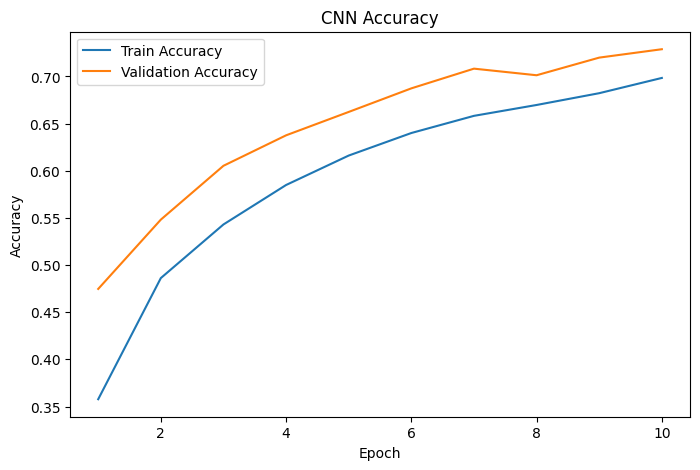

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

ทำ confusion matrix

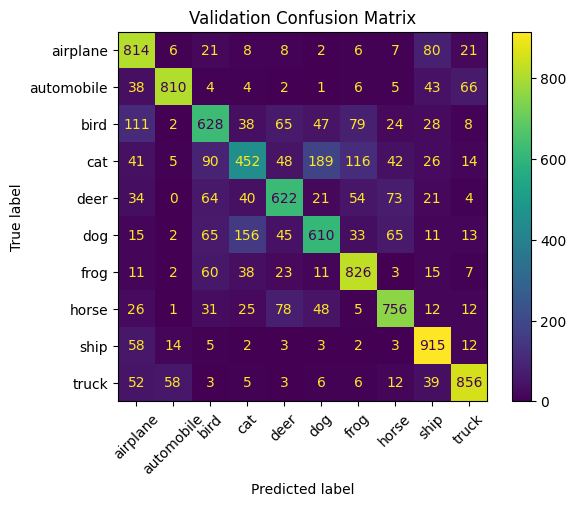

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_train_dataset.classes)
disp.plot(xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.show()